# **Análisis de tópicos (LDA)**

En este notebook analizamos los tópicos predominantes en nuestro dataset.

In [3]:
!pip install pandas numpy matplotlib seaborn gensim scikit-learn sentence-transformers umap-learn spacy tqdm
# !python -m spacy download es_core_news_sm

  Using cached gensim-4.4.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (8.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 93.2 MB/s eta 0:00:00


In [4]:
import os
import re
import itertools
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# NLP
import spacy

# Gensim
from gensim.corpora import Dictionary
from gensim.models import LdaModel
try:
    from gensim.models.ldaseqmodel import LdaSeqModel
    has_ldaseq = True
except Exception:
    has_ldaseq = False

# Embeddings & dimensionality reduction
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.metrics.pairwise import cosine_similarity
import umap.umap_ as umap
from sklearn.feature_extraction.text import CountVectorizer

## **1. Carga de datos**

In [5]:
df = pd.read_csv('dataset_universidades_procesado.csv')

df['Fecha_Publicacion'] = pd.to_datetime(df['Fecha_Publicacion'], errors='coerce')
df = df.dropna(subset=['Fecha_Publicacion']).sort_values('Fecha_Publicacion').reset_index(drop=True)

print("Dimensiones:", df.shape)
print("Rango temporal:", df['Fecha_Publicacion'].min(), "-", df['Fecha_Publicacion'].max())


Dimensiones: (162574, 14)
Rango temporal: 1995-01-02 00:00:00 - 2024-01-30 00:00:00


## **2. Preprocesamiento específico**

En esta sección se aplica un proceso de limpieza y normalización de texto a los titulares del BOE utilizando la librería spaCy para el idioma español.

Primero, cargamos el modelo es_core_news_sm de spaCy, desactivando los componentes de parser y NER (reconocimiento de entidades) para mejorar el rendimiento.

La función preprocess_text_spacy() realiza los siguientes pasos:

- Convierte el texto a minúsculas y elimina espacios sobrantes.

- Tokeniza y lematiza el texto con spaCy.

- Elimina puntuación, espacios, stopwords y palabras muy cortas (≤ 2 caracteres).

- Excluye términos incluidos en la lista de stopwords adicionales.

- Devuelve una lista de tokens limpios y representativos del texto original.

Después, esta función se aplica a la columna texto_lower del DataFrame, creando dos nuevas columnas:

- processed_tokens: lista de tokens limpios para cada titular.

- processed_text: texto reconstruido uniendo los tokens.

In [6]:
# Cargar spaCy español
try:
    nlp = spacy.load("es_core_news_sm", disable=["parser", "ner"])
except Exception:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "spacy", "download", "es_core_news_sm"])
    nlp = spacy.load("es_core_news_sm", disable=["parser", "ner"])


def preprocess_text_spacy(text):
    if not isinstance(text, str):
        text = ""
    # limpiamos primero
    text = text.strip()

    # Procesar con spaCy
    doc = nlp(text.lower())
    tokens = []
    for tok in doc:
        # descartamos puntuación, espacios y tokens muy cortos
        if tok.is_space or tok.is_punct or tok.is_stop:
            continue
        lemma = tok.lemma_.strip()
        if not lemma:
            continue
        if len(lemma) <= 2:
            continue
        # eliminar caracteres que no sean letras o guion medio
        if lemma and len(lemma) > 2:
            tokens.append(lemma)
    return tokens

# Aplicar preprocesamiento
tqdm.pandas(desc="Preprocesando textos")
df['processed_tokens'] = df['texto_lower'].progress_apply(preprocess_text_spacy)
df['processed_text'] = df['processed_tokens'].apply(lambda toks: " ".join(toks))


print("\nEjemplo:")
print("Original:", df['Titulo_Semantico'].iloc[0])
print("Procesado tokens:", df['processed_tokens'].iloc[0])


Preprocesando textos: 100%|██████████| 162574/162574 [08:37<00:00, 313.90it/s]



Ejemplo:
Original: Resolución de 30 de noviembre de 1994, de la Universidad Politécnica de Madrid, por la que se convoca a libre designación, entre funcionarios de carrera, puesto vacante en esta Universidad.
Procesado tokens: ['resolucion', 'politecnico', 'madrid', 'convocar', 'libre', 'designacion', 'carrera', 'vacante']


## **3. Bolsa de palabras**

En esta fase se transforma el texto en una representación numérica mediante el modelo de Bolsa de Palabras (Bag of Words) utilizando CountVectorizer de scikit-learn.

Cada documento (titular) se convierte en un vector donde cada posición indica la frecuencia de una palabra en el corpus. Para ello, se utilizan los textos ya preprocesados (processed_text) y se aplican filtros para mejorar la calidad del vocabulario: se eliminan palabras demasiado raras (min_df=10) o demasiado frecuentes (max_df=0.001), se limita el vocabulario a 20.000 términos más representativos y solo se consideran palabras alfabéticas de al menos tres letras.

El resultado es una matriz dispersa donde las filas representan documentos y las columnas palabras, reflejando su frecuencia de aparición.

In [7]:
documents = df['processed_text'].tolist()

# Vectorizador (bag of words)
tf_vectorizer = CountVectorizer(
    min_df=10,           # eliminar palabras muy raras (aparecen en < 4 documentos)
    max_df=0.001,         # eliminar palabras demasiado frecuentes (> 20% de documentos)
    lowercase=True,
    max_features=20000, # tamaño máximo del vocabulario
    token_pattern='[a-zA-Záéíóúñü]{3,}',  # palabras alfabéticas de al menos 3 letras
    analyzer='word'
)

# Ajustar y transformar
bag_of_words = tf_vectorizer.fit_transform(documents)
dictionary = tf_vectorizer.get_feature_names_out()
vocabulary = tf_vectorizer.vocabulary_

print("\nTamaño vocabulario tras filtros:", len(dictionary))
print("Dimensión matriz:", bag_of_words.shape)


Tamaño vocabulario tras filtros: 3546
Dimensión matriz: (162574, 3546)


## **4. Análisis de palabras más frecuentes**
Ahora, comprobamos si las palabras más frecuentes después del preproceso tienen valor semántico.

In [8]:
# Obtener las palabras más frecuentes
word_counts = np.asarray(bag_of_words.sum(axis=0)).ravel()
freq_df = pd.DataFrame({
    'palabra': dictionary,
    'frecuencia': word_counts
}).sort_values('frecuencia', ascending=False)

print("\nTop 20 palabras más frecuentes:")
print(freq_df.head(20))


Top 20 palabras más frecuentes:
              palabra  frecuencia
3381              usc         216
654      cartografico         216
199          anatomia         209
1466    fotogrametria         197
1453         forestal         197
316       asistencial         192
1072           dibujo         177
3235          tension         172
2561            penal         171
2584     personalidad         170
459   biblioteconomia         168
1384     farmacologia         168
922          corporal         165
680           catalán         164
1214       energetico         164
923       corporativo         162
193            amparo         162
989            cuenta         162
1406           ferrer         162
171            alumno         161


Sí que vemos palabras más específicas como anatomía, forestal, fotogrametria, etc.

## **5. Periodos quinquenales**

También, se comprueba el volumen de disposiciones por quinquenio para ver si hay algún sesgo.


Quinquenios detectados: [np.int32(1995), np.int32(2000), np.int32(2005), np.int32(2010), np.int32(2015), np.int32(2020)]


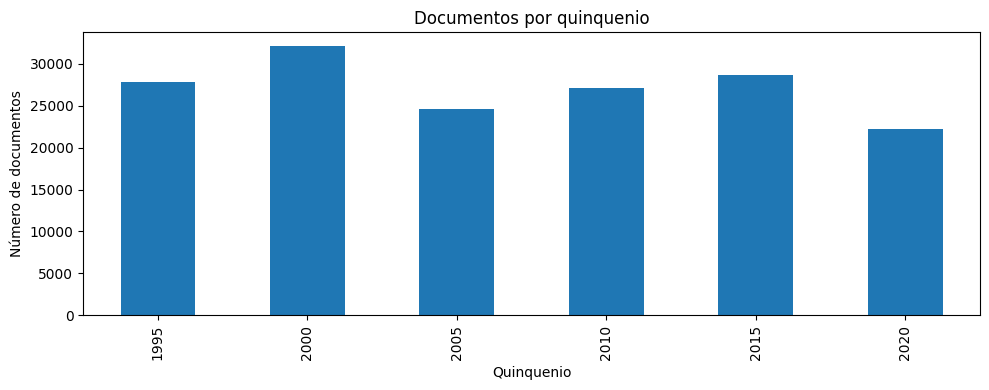

In [9]:
# Periodo quinquenal: ej 1995 -> 1995, 1999 -> 1995, 2000 -> 2000, etc.
df['quinquenio'] = (df['Fecha_Publicacion'].dt.year // 5) * 5
quinquenios = sorted(df['quinquenio'].unique())
print("\nQuinquenios detectados:", quinquenios)

# Conteo por quinquenio
counts_q = df.groupby('quinquenio').size()
plt.figure(figsize=(10,4))
counts_q.plot(kind='bar')
plt.title('Documentos por quinquenio')
plt.xlabel('Quinquenio')
plt.ylabel('Número de documentos')
plt.tight_layout()
plt.show()

## **6. Tamaño del vocabulario final**

El tamaño del vocabulario después de todo el procesamiento es de 7065 palabras, muy reducido teniendo en cuenta que nos tenemos 160 mil disposiciones.

In [10]:
dictionary = Dictionary(df['processed_tokens'])
# Filtramos: palabras que aparecen en menos de 5 documentos o en más del 50% de docs
dictionary.filter_extremes(no_below=5, no_above=0.3)
print("\nTamaño vocabulario tras filtros:", len(dictionary))

corpus = [dictionary.doc2bow(doc) for doc in df['processed_tokens']]


Tamaño vocabulario tras filtros: 7065


## **7. LDA por quinquenio**

En esta fase se aplica el modelo LDA (Latent Dirichlet Allocation) para identificar los principales tópicos o temas recurrentes en los titulares del BOE, analizando cómo evolucionan a lo largo del tiempo.

El análisis se realiza por quinquenios (bloques de cinco años), con el objetivo de observar la aparición y evolución de distintos temas institucionales en distintos periodos históricos.

El número de tópicos por quinquenio que hemos elegido es 8, un número equilibrado que permite distinguir temas relevantes sin fragmentar demasiado la información.


In [11]:
num_topics = 8
passes = 20
random_state = 42

# Entrenar un LDA por quinquenio y guardar resultados
lda_per_q = {}
corpus_per_q = {}
dictionary_per_q = {}

for q in quinquenios:
    docs = df[df['quinquenio'] == q]['processed_tokens'].tolist()
    if len(docs) < 10:
        print(f"Quinquenio {q}: pocos documentos ({len(docs)}), se omite LDA")
        continue
    dict_q = Dictionary(docs)
    dict_q.filter_extremes(no_below=3, no_above=0.6)
    corpus_q = [dict_q.doc2bow(d) for d in docs]
    if len(dict_q) < 10:
        print(f"Quinquenio {q}: vocabulario muy pequeño ({len(dict_q)}), se omite")
        continue
    lda = LdaModel(corpus=corpus_q, id2word=dict_q, num_topics=num_topics,
                   passes=passes, random_state=random_state, chunksize=1000)
    lda_per_q[q] = lda
    corpus_per_q[q] = corpus_q
    dictionary_per_q[q] = dict_q
    print(f"Entrenado LDA para quinquenio {q} (docs={len(docs)}, vocab={len(dict_q)})")

# Función para obtener top-k palabras de cada tópico
def top_terms_lda(lda_model, k=10):
    topics = {}
    for tid in range(lda_model.num_topics):
        terms = lda_model.show_topic(tid, topn=k)
        topics[tid] = [t for t, w in terms]
    return topics


for q, lda in lda_per_q.items():
    print(f"\nQuinquenio {q} - top términos por tópico:")
    topics = top_terms_lda(lda, k=8)
    for tid, terms in topics.items():
        print(f" Tópico {tid}: {', '.join(terms)}")

Entrenado LDA para quinquenio 1995 (docs=27764, vocab=3433)
Entrenado LDA para quinquenio 2000 (docs=32136, vocab=3864)
Entrenado LDA para quinquenio 2005 (docs=24630, vocab=3086)
Entrenado LDA para quinquenio 2010 (docs=27071, vocab=3543)
Entrenado LDA para quinquenio 2015 (docs=28699, vocab=3526)
Entrenado LDA para quinquenio 2020 (docs=22274, vocab=1882)

Quinquenio 1995 - top términos por tópico:
 Tópico 0: autonomo, educacion, burgo, nacional, distancia, barcelona, valladolid, madrid
 Tópico 1: concurso, publico, contratacion, anunciar, adjudicacion, obra, abierto, politecnico
 Tópico 2: area, conocimiento, departamento, dona, catedratico, adscritar, aplicado, jose
 Tópico 3: estudio, plan, titulo, licenciado, publicacion, ordenar, conducente, ciencia
 Tópico 4: alcala, mancha, prueba, castilla, convocar, sistema, ingreso, libre
 Tópico 5: convocar, concurso, madrid, publico, complutense, citar, murcia, provision
 Tópico 6: area, conocimiento, dona, mario, catedratico, profesoro, 

Aunque aparecen términos comunes en todos los quinquenios —como título, resolución, concurso, catedrático o universidad—, los resultados no aportan información realmente útil sobre los temas tratados.

Esto se debe a que los titulares del BOE tienen un lenguaje muy formal y repetitivo, centrado en expresiones legales o administrativas.
Por eso, el modelo acaba agrupando palabras que se repiten por formato (como nombres de universidades o cargos) y no por significado o tema real.

In [12]:
df.to_csv("dataset_universidades_preprocesado_topics.csv")
print("Archivo guardado")

Archivo guardado
